#### State Schema with DataClasses

When we define a Langgraph StateGraph, we use a state schema

THe state schema represents the structure and types of data that our graph will use

All nodes are expected to communicate with that schema

Langgraph offers flexibility in how you define your state schema, accomdating various Python types and validation approches

we can use the TypeDict class from python's typing module

It allows you to specify keys and their corresponding value type

But, note that these are type hints

They can be used bt static type checkers (like mypy) or IDEs to catch potential type-related errors before the code run.

But they are not  enforced at runtime

In [1]:
from typing_extensions import TypedDict
from typing import Literal

class TypedDictState(TypedDict):
    name:str
    game:Literal["cricket", "badminton"]

In [7]:
def play_game(state:TypedDictState):
    print("---Play Game node has been called--")
    return {"name": state['name'] + ' want to play '}

def cricket(state:TypedDictState):
    print("-- Cricket node has been called")
    return {"name":state["name"] + " badminton", "game": "cricket"}

def badminton(state:TypedDictState):
    print("-- Badminton node has been called")
    return {"name":state["name"] + " badminton", "game": "badminton"}

In [8]:
import random
def decide_play(state: TypedDictState)->Literal["cricket", "badminton"]:
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() <0.5:
        return "cricket"
    else:
        return "badminton"

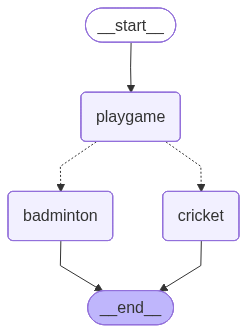

In [9]:
import random
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

## Build Graph
graph=StateGraph(TypedDictState)

## Adding the nodes
graph.add_node("playgame",play_game)
graph.add_node("cricket",cricket)
graph.add_node("badminton",badminton)

## Schedule the flow of the graph

graph.add_edge(START,"playgame")
graph.add_conditional_edges("playgame",decide_play)
graph.add_edge("cricket",END)
graph.add_edge("badminton",END)

## Compile the graph
graph_builder=graph.compile()

## View
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [10]:
graph_builder.invoke({"name":"Venkey"})

---Play Game node has been called--
-- Badminton node has been called


{'name': 'Venkey want to play  badminton', 'game': 'badminton'}

#### Data Classes

Python's dataclasses provides another way to define structured data.

DataClasses offers a concise syntax for creating  classes that are primarily used to store data.

In [11]:
## DataClasses

from dataclasses import dataclass

@dataclass
class DataClassState:
    name:str
    game:Literal["badminton","cricket"]

In [12]:
def play_game(state:DataClassState):
    print("---Play Game node has been called--")
    return {"name": state.name + ' want to play '}

def cricket(state:DataClassState):
    print("-- Cricket node has been called")
    return {"name":state.name + " badminton", "game": "cricket"}

def badminton(state:DataClassState):
    print("-- Badminton node has been called")
    return {"name":state.name + " badminton", "game": "badminton"}

In [13]:
import random
def decide_play(state: DataClassState)->Literal["cricket", "badminton"]:
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() <0.5:
        return "cricket"
    else:
        return "badminton"

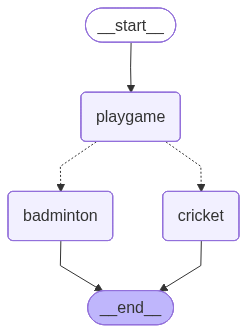

In [15]:
import random
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

## Build Graph
builder=StateGraph(DataClassState)

## Adding the nodes
builder.add_node("playgame",play_game)
builder.add_node("cricket",cricket)
builder.add_node("badminton",badminton)

## Schedule the flow of the graph

builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("badminton",END)

## Compile the graph
graph=builder.compile()

## View
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [16]:
graph.invoke(DataClassState(name="Venkey", game="cricket"))

---Play Game node has been called--
-- Badminton node has been called


{'name': 'Venkey want to play  badminton', 'game': 'badminton'}